In [1]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(18)   # correctly seeding

N_points = 40
N_Neurons = N_points * 2

t = np.linspace(0, np.pi * 2, N_points)
x = np.cos(t) + (np.random.rand(N_points) - .5) * .3
y = np.sin(t) + (np.random.rand(N_points) - .5) * .3

In [3]:
som = MiniSom(
    1, N_Neurons, 2,
    sigma=8,
    learning_rate=0.4,
    neighborhood_function='gaussian',   # corrected spelling
    random_seed=0
)

points = np.array([x, y]).T
som.random_weights_init(points)

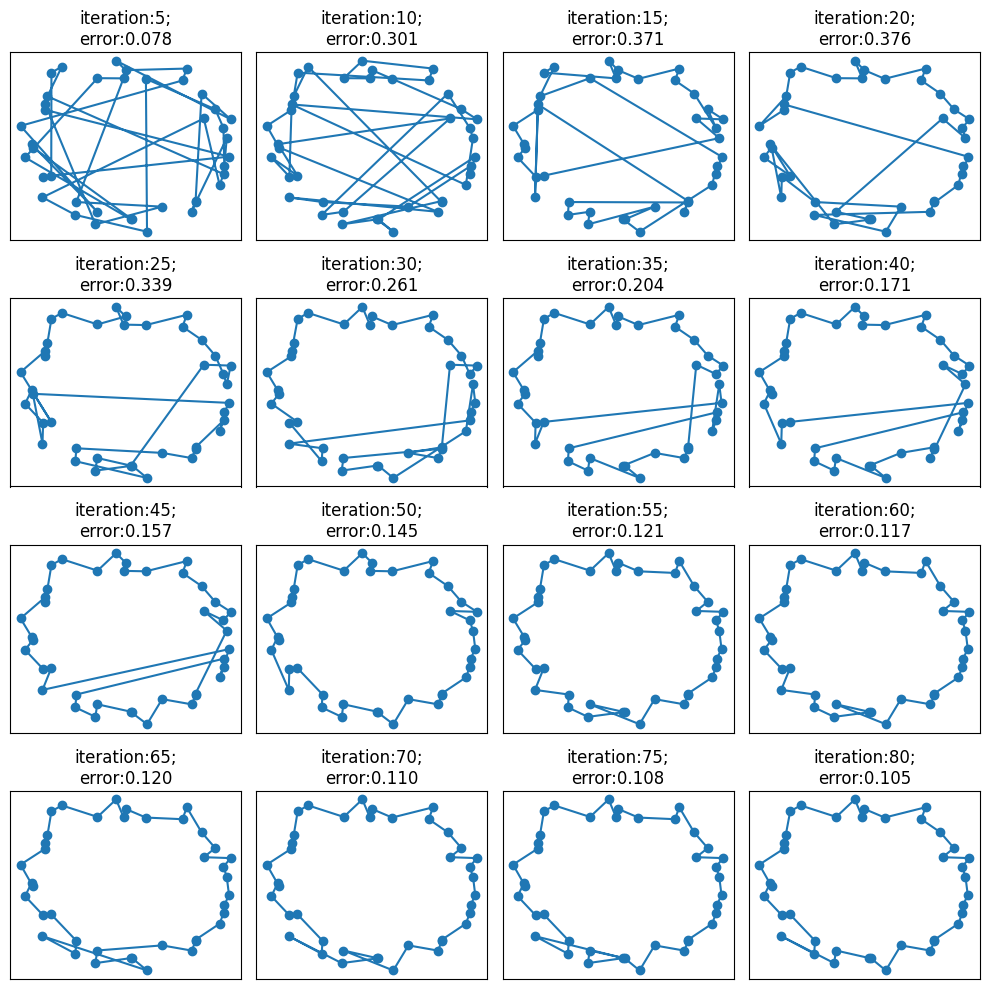

In [4]:
plt.figure(figsize=(10, 10))

for i, iteration in enumerate(range(5, 81, 5)):
    som.train(points, iteration, verbose=False, random_order=False)

    plt.subplot(4, 4, i + 1)
    plt.scatter(x, y)

    # Get winners in neuron order
    winner_indices = np.argsort([som.winner(p)[1] for p in points])
    winner_indices = np.append(winner_indices, winner_indices[0])  # close the loop

    plt.plot(points[winner_indices][:, 0], points[winner_indices][:, 1])

    plt.title('iteration:{i};\nerror:{e:.3f}'.format(
        i=iteration,
        e=som.quantization_error(points)
    ))
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()